In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from textblob import TextBlob
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
import re

In [ ]:
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/yiweilu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/yiweilu/nltk_data...


True

In [ ]:
file_path = 'Airbnb.xlsx'  # 确保文件和Notebook在同一个目录下
df = pd.read_excel(file_path, sheet_name='Reviews')

In [ ]:
print("数据预览：")
print(df.head())

print("\n列名列表：")
print(df.columns)

数据预览：
   listing_id        id       date  reviewer_id reviewer_name  \
0     7202016  38917982 2015-07-19     28943674        Bianca   
1     7202016  39087409 2015-07-20     32440555         Frank   
2     7202016  39820030 2015-07-26     37722850           Ian   
3     7202016  40813543 2015-08-02     33671805        George   
4     7202016  41986501 2015-08-10     34959538          Ming   

                                            comments  
0  Cute and cozy place. Perfect location to every...  
1  Kelly has a great room in a very central locat...  
2  Very spacious apartment, and in a great neighb...  
3  Close to Seattle Center and all it has to offe...  
4  Kelly was a great host and very accommodating ...  

列名列表：
Index(['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments'], dtype='object')


In [ ]:
df = df.dropna(subset=['comments'])

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # 只保留英文字符和空格
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['cleaned_comments'] = df['comments'].astype(str).apply(clean_text)


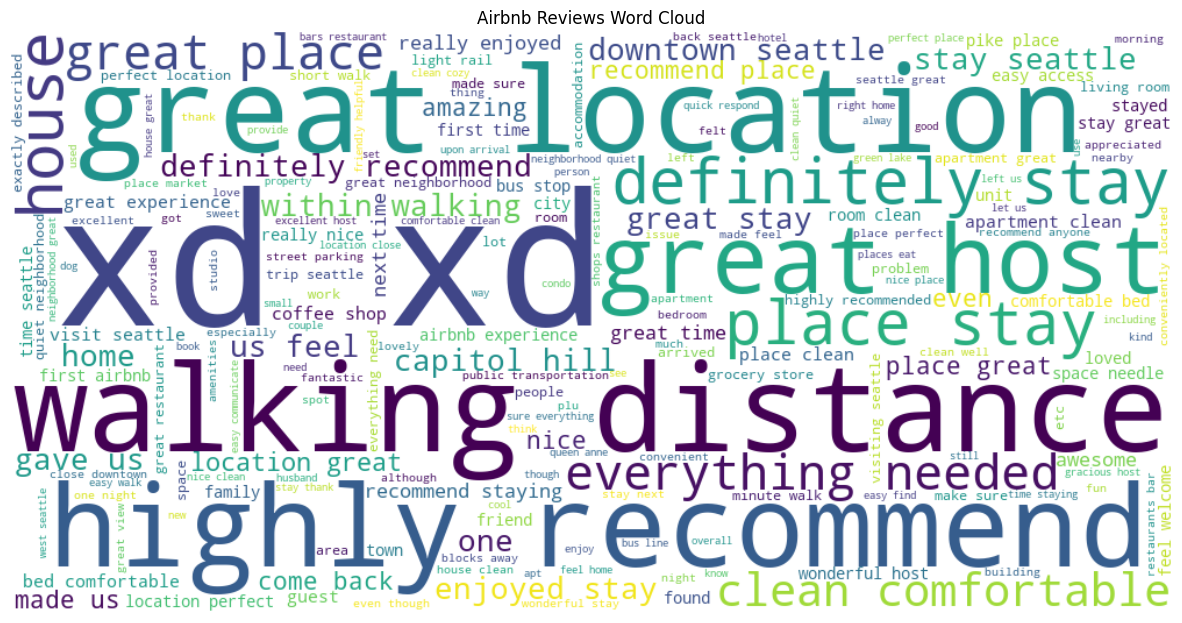

In [ ]:
all_text = ' '.join(df['cleaned_comments'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=200,
    colormap='viridis'
).generate(all_text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Airbnb Reviews Word Cloud')
plt.show()

In [ ]:
# 7. TextBlob情感分析
df['sentiment_blob'] = df['comments'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)


In [ ]:

# 8. VADER情感分析
sia = SentimentIntensityAnalyzer()
df['sentiment_vader'] = df['comments'].astype(str).apply(lambda x: sia.polarity_scores(x)['compound'])


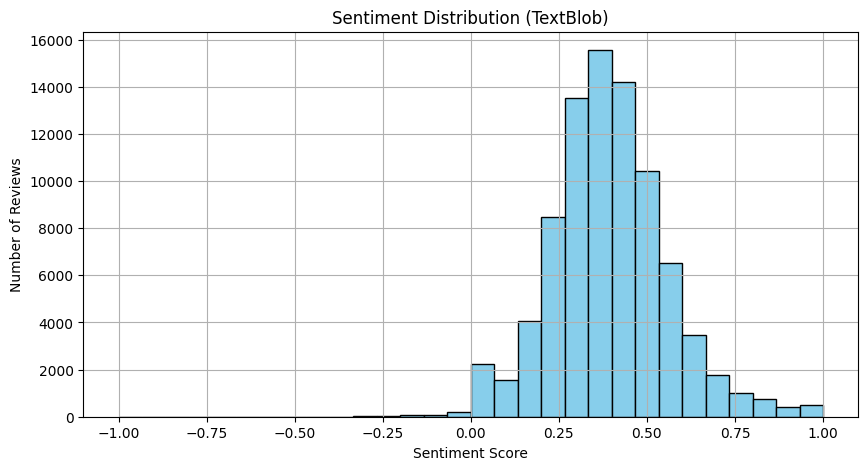

In [ ]:
# 9. 情感分布图（TextBlob版本）
plt.figure(figsize=(10, 5))
plt.hist(df['sentiment_blob'], bins=30, color='skyblue', edgecolor='black')
plt.title('Sentiment Distribution (TextBlob)')
plt.xlabel('Sentiment Score')
plt.ylabel('Number of Reviews')
plt.grid(True)
plt.show()


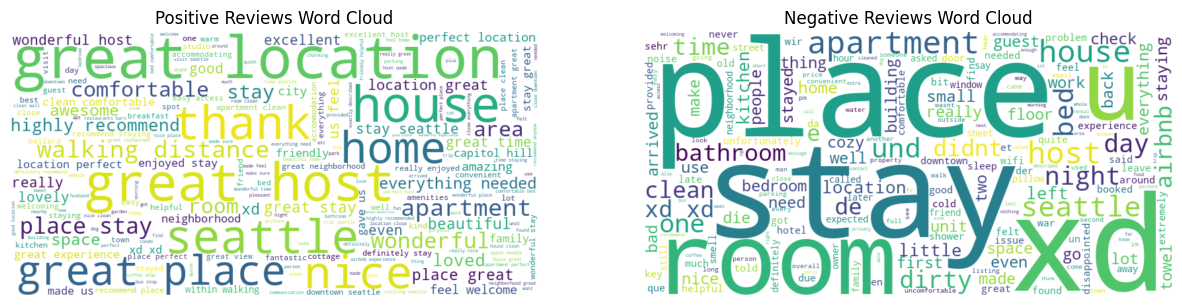

In [ ]:
# 10. 好评 vs 差评词云
good_reviews = df[df['sentiment_blob'] > 0.5]['cleaned_comments']
bad_reviews = df[df['sentiment_blob'] < 0]['cleaned_comments']

good_text = ' '.join(good_reviews)
bad_text = ' '.join(bad_reviews)

good_wc = WordCloud(width=800, height=400, background_color='white').generate(good_text)
bad_wc = WordCloud(width=800, height=400, background_color='white').generate(bad_text)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(good_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews Word Cloud')

plt.subplot(1, 2, 2)
plt.imshow(bad_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews Word Cloud')

plt.show()

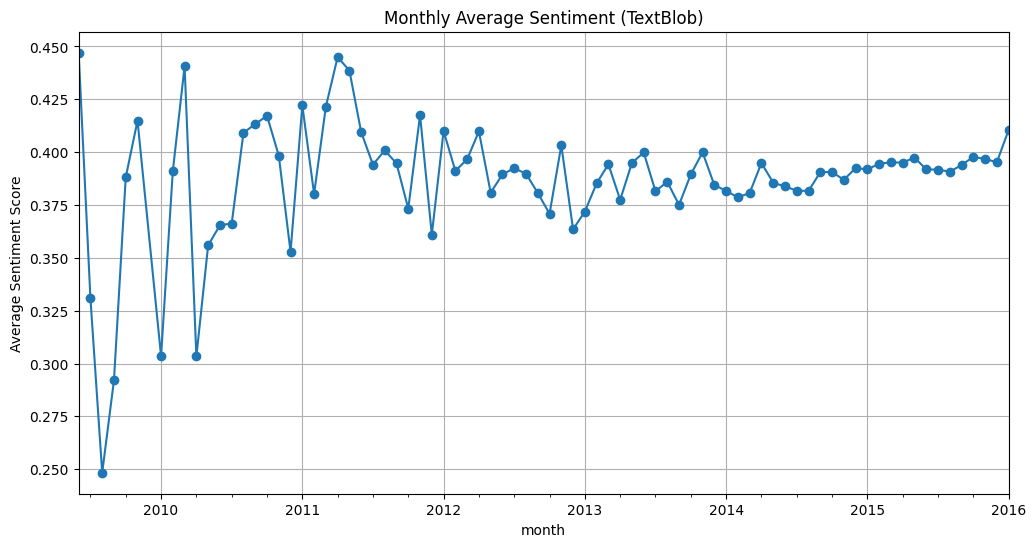

In [ ]:
# 12. 时间趋势分析（按月份）
df['date'] = pd.to_datetime(df['date'], errors='coerce')  # 处理格式异常
df = df.dropna(subset=['date'])  # 去掉没有日期的
df['month'] = df['date'].dt.to_period('M')

monthly_sentiment = df.groupby('month')['sentiment_blob'].mean()

plt.figure(figsize=(12, 6))
monthly_sentiment.plot(marker='o', linestyle='-')
plt.title('Monthly Average Sentiment (TextBlob)')
plt.ylabel('Average Sentiment Score')
plt.grid(True)
plt.show()

In [ ]:
# 13. 主题建模（LDA）
vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['cleaned_comments'])

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(tfidf_matrix)

terms = vectorizer.get_feature_names_out()

for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx+1}:")
    print([terms[i] for i in topic.argsort()[-10:]])

Topic 1:
['apartment', 'place', 'experience', 'great', 'amazing', 'feel', 'stay', 'home', 'seattle', 'xd']
Topic 2:
['comfortable', 'room', 'location', 'clean', 'apartment', 'easy', 'nice', 'stay', 'place', 'great']
Topic 3:
['distance', 'seattle', 'home', 'host', 'location', 'walking', 'place', 'stay', 'house', 'great']


In [ ]:
# 获取每条评论的主题分布（LDA transform）
topic_distribution = lda.transform(tfidf_matrix)

# 添加到原始DataFrame中（每条评论3个主题的占比）
df['topic_1'] = topic_distribution[:, 0]
df['topic_2'] = topic_distribution[:, 1]
df['topic_3'] = topic_distribution[:, 2]

# 查看前几条评论的主题分布
print(df[['comments', 'topic_1', 'topic_2', 'topic_3']].head())

                                            comments   topic_1   topic_2  \
0  Cute and cozy place. Perfect location to every...  0.120107  0.137397   
1  Kelly has a great room in a very central locat...  0.818679  0.087663   
2  Very spacious apartment, and in a great neighb...  0.729293  0.170838   
3  Close to Seattle Center and all it has to offe...  0.102769  0.284620   
4  Kelly was a great host and very accommodating ...  0.431235  0.114509   

    topic_3  
0  0.742496  
1  0.093657  
2  0.099869  
3  0.612611  
4  0.454257  


In [ ]:
for i in range(3):
    print(f"\nTop comments for Topic {i+1}:")
    top_comments = df.sort_values(f'topic_{i+1}', ascending=False).head(5)
    print(top_comments['comments'].tolist())


Top comments for Topic 1:
['This was our first AirBnb experience and it went perfectly! Well, except for my son getting food poisoning (before we arrived) and spending our first day in the Seattle Children\'s Hospital ER, which is fantastic btw!_x000D_\n_x000D_\nJoe and Shannon were wonderful hosts and the downstairs apartment that we stayed in was amazing! Just what we needed while my son was recovering. Fortunately he wasn\'t down for too long and he was still able to attend the Russell Wilson Passing Academy and spend the next day sightseeing. The Uber service that Shannon recommended was great! It\'s definitely the way to get around up there!_x000D_\n_x000D_\nThey provide everything that you need, extra blankets, towels, etc. They also generously provided snacks and drinks which we very much appreciated when we arrived at Joe and Shannon\'s starving (our train was late getting into the station and we didn\'t have a chance to eat). Bed was very comfortable and the rooms were spacio